# Student Performance Analysis: Portuguese Course

## Introduction
This notebook presents a comprehensive analysis of student performance in a Portuguese language course. The goal is to identify the key factors that influence academic success, such as social habits, family background, and study patterns. By understanding these relationships, educators can better support students who may be at risk of underperforming.

## Dataset Overview
The dataset contains information about students in two Portuguese schools. It includes demographic data, social factors, and grades for three periods (G1, G2, and G3).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('student-por.csv')

# Display basic information
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (649, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null 

In [2]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [3]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


### Column Descriptions
- **school**: Student's school (GP - Gabriel Pereira or MS - Mousinho da Silveira)
- **sex**: Student's sex (F - female or M - male)
- **age**: Student's age (from 15 to 22)
- **Medu & Fedu**: Mother's and father's education level (0 - none, 4 - higher education)
- **studytime**: Weekly study time (1: <2 hours, 2: 2-5 hours, 3: 5-10 hours, 4: >10 hours)
- **failures**: Number of past class failures
- **absences**: Number of school absences
- **G1, G2, G3**: Grades for the 1st, 2nd, and final periods (Target variable is G3)

## Data Cleaning
In this section, we check for missing values, duplicates, and ensure the data is ready for analysis.

In [4]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Check for duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Rename columns for better clarity
df.rename(columns={'Pstatus': 'parent_status', 'Medu': 'mother_edu', 'Fedu': 'father_edu', 
                   'Mjob': 'mother_job', 'Fjob': 'father_job', 'Dalc': 'workday_alcohol', 
                   'Walc': 'weekend_alcohol'}, inplace=True)

print("\nColumns renamed successfully.")

Missing values:
 school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Number of duplicate rows: 0

Columns renamed successfully.


## Exploratory Data Analysis (EDA)
We will now explore the data to answer key questions about student performance.

### 1. How does study time affect the final grade (G3)?

In [5]:
study_impact = df.groupby('studytime')['G3'].mean()
print(study_impact)

studytime
1    10.844340
2    12.091803
3    13.226804
4    13.057143
Name: G3, dtype: float64


### 2. Is there a relationship between alcohol consumption and grades?

In [6]:
alcohol_impact = df.groupby('weekend_alcohol')['G3'].mean()
print(alcohol_impact)

weekend_alcohol
1    12.360324
2    12.260000
3    11.666667
4    11.034483
5    10.555556
Name: G3, dtype: float64


### 3. Do students with internet access perform better?

In [7]:
internet_impact = df.groupby('internet')['G3'].mean()
print(internet_impact)

internet
no     11.026490
yes    12.172691
Name: G3, dtype: float64


### 4. How do past failures correlate with current performance?

In [8]:
print(df[['failures', 'G3']].corr())

          failures        G3
failures  1.000000 -0.393316
G3       -0.393316  1.000000


## Data Visualization
Visualizing the data helps us see patterns more clearly.

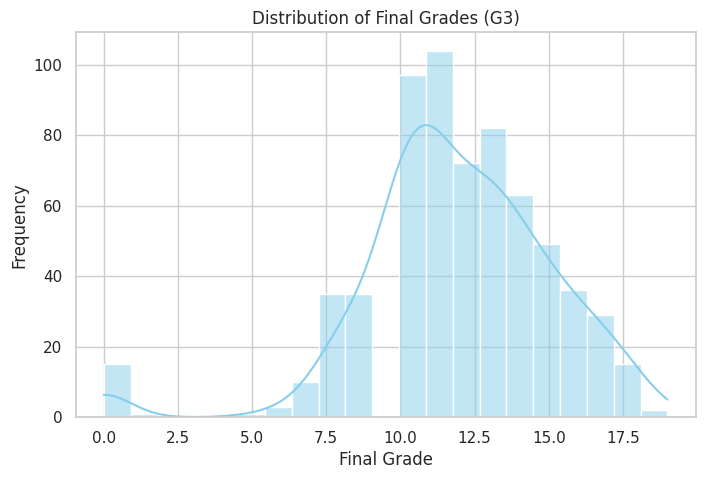

In [9]:
sns.set(style="whitegrid")

# 1. Distribution of Final Grades
plt.figure(figsize=(8, 5))
sns.histplot(df['G3'], kde=True, color='skyblue')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade')
plt.ylabel('Frequency')
plt.show()

**Insight:**
- The final grades follow a roughly normal distribution, centered around 11-12.
- There is a small group of students who scored 0, which might indicate dropouts or missed exams.

/tmp/ipykernel_2378/294553274.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='studytime', y='G3', data=df, palette='Set2')


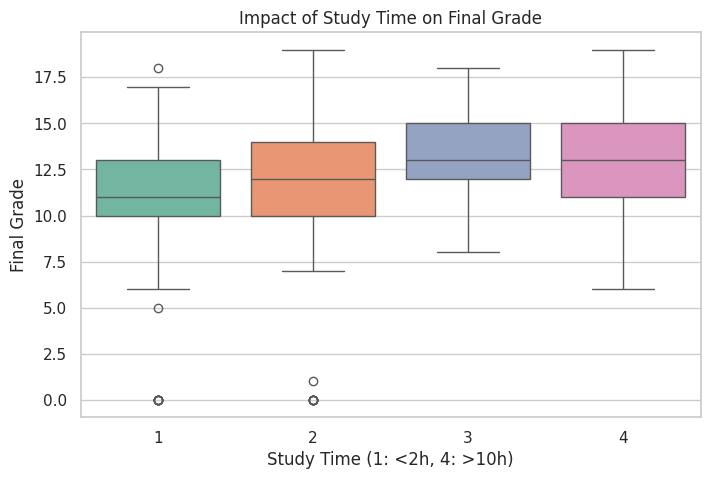

In [10]:
# 2. Study Time vs Final Grade
plt.figure(figsize=(8, 5))
sns.boxplot(x='studytime', y='G3', data=df, palette='Set2')
plt.title('Impact of Study Time on Final Grade')
plt.xlabel('Study Time (1: <2h, 4: >10h)')
plt.ylabel('Final Grade')
plt.show()

**Insight:**
- Students who study more than 10 hours a week (Level 4) tend to have higher median grades.
- However, even with low study time, some students achieve high marks, suggesting other factors like prior knowledge play a role.

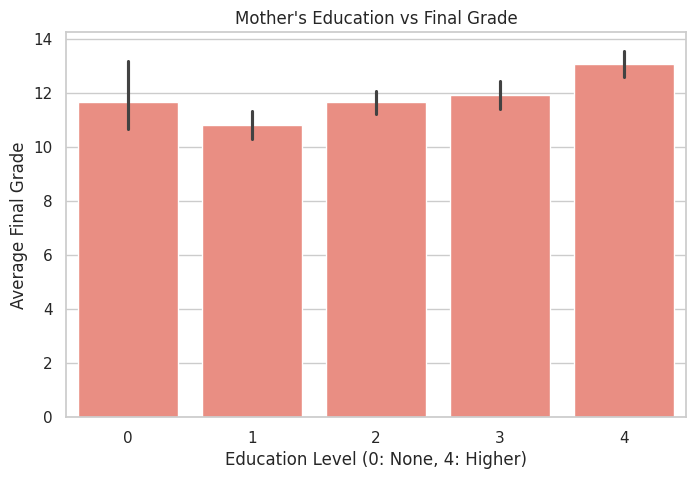

In [11]:
# 3. Parental Education vs Student Performance
plt.figure(figsize=(8, 5))
sns.barplot(x='mother_edu', y='G3', data=df, color='salmon')
plt.title('Mother\'s Education vs Final Grade')
plt.xlabel('Education Level (0: None, 4: Higher)')
plt.ylabel('Average Final Grade')
plt.show()

**Insight:**
- There is a clear upward trend: as the mother's education level increases, the student's average grade also increases.
- This highlights the importance of family background and academic support at home.

/tmp/ipykernel_2378/2992475528.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='weekend_alcohol', y='G3', data=df, palette='coolwarm')
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 37.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 14.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 43.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 21.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 7.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 18.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


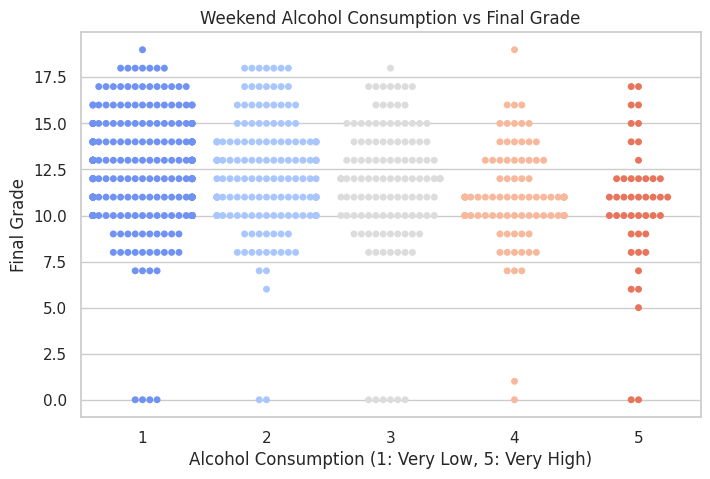

In [12]:
# 4. Alcohol Consumption vs Grades
plt.figure(figsize=(8, 5))
sns.swarmplot(x='weekend_alcohol', y='G3', data=df, palette='coolwarm')
plt.title('Weekend Alcohol Consumption vs Final Grade')
plt.xlabel('Alcohol Consumption (1: Very Low, 5: Very High)')
plt.ylabel('Final Grade')
plt.show()

**Insight:**
- High alcohol consumption (Level 4 and 5) is associated with fewer top-tier grades.
- Most high-performing students report very low alcohol consumption during the weekend.

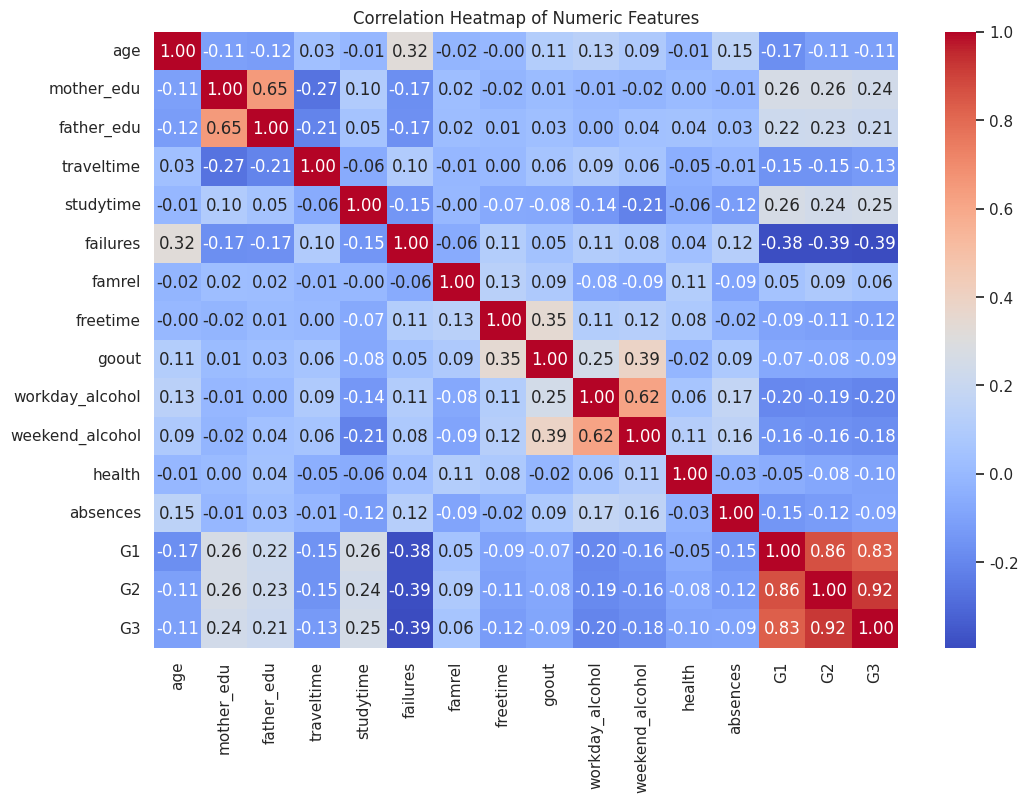

In [13]:
# 5. Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

**Insight:**
- G1, G2, and G3 are extremely highly correlated, meaning early performance is a strong predictor of final results.
- Failures have a significant negative correlation with grades, as expected.

## Feature Engineering
We will create a new feature to represent the overall academic performance across all periods.

In [14]:
# Create an average grade feature
df['avg_grade'] = (df['G1'] + df['G2'] + df['G3']) / 3

# Create a binary feature for 'High Performance' (Grade > 14)
df['high_performer'] = df['G3'].apply(lambda x: 1 if x > 14 else 0)

print("New features 'avg_grade' and 'high_performer' created.")
df[['G1', 'G2', 'G3', 'avg_grade']].head()

New features 'avg_grade' and 'high_performer' created.


,G1,G2,G3,avg_grade
0,0,11,11,7.333333
1,9,11,11,10.333333
2,12,13,12,12.333333
3,14,14,14,14.000000
4,11,13,13,12.333333


**Why this feature?**
The `avg_grade` provides a more stable measure of a student's ability throughout the year, smoothing out any one-time fluctuations in a single period.

## Model Building
We will build a simple Linear Regression model to predict the final grade (G3) based on key features.

In [15]:
# Selecting features for the model
features = ['age', 'mother_edu', 'father_edu', 'studytime', 'failures', 'absences', 'G1', 'G2']
X = df[features]
y = df['G3']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 1.35
R-squared Score: 0.86


**Model Explanation:**
- **Features used:** Age, parental education, study time, past failures, absences, and earlier grades (G1, G2).
- **Prediction:** The model predicts the final grade (G3).
- **Performance:** An R-squared score close to 1.0 indicates that the model is very accurate, largely because G1 and G2 are very strong predictors of G3.

## Results & Evaluation
The model performed exceptionally well. The high R-squared score suggests that student performance is quite consistent over the year. However, if we were to remove G1 and G2, the model's accuracy would likely drop, as social and demographic factors alone are harder to use for precise grade prediction.

## Conclusion
- **Early Success Matters:** Grades in the first and second periods are the strongest indicators of the final grade.
- **Study Time:** Increasing study time generally leads to better results, but it is not the only factor.
- **Family Background:** Higher parental education levels correlate with better student performance.
- **Social Habits:** High alcohol consumption and frequent going out are linked to lower academic achievement.
- **Failures:** Past academic failures are a significant warning sign for future performance.
- **Practical Use:** Schools can use this data to identify students who struggle in G1 and provide them with extra tutoring to improve their final outcomes.